In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy import constants, units
from astropy.coordinates import Angle
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from gwcs.wcstools import wcs_from_points
import astropy.coordinates as coord

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/CUBS/Data/PG1522+101/'

We'll use a set of four reference stars, cross-identified across MUSE and HST images. Here are the physical coordinates of the stars in MUSE -

In [1]:
# The coordinate system here begins at (1,1)
star_coords_MUSE = np.array([[35,122], [26,108], [142,287], [190,200]])

# The coordinate system here also probably begins at (1,1)
star_coords_F160W = np.array([[357.904, 402.589], [351.305,376.484], [440.782, 697.099], [552.83, 588.29]])

# The coordinate system here also probably begins at (1,1)
star_coords_F140W = np.array([[347.241, 399.667], [340.296,372.468], [430, 694], [542, 585]])

NameError: name 'np' is not defined

Next order of business, we need to read off the star RA and Dec in F160W coordinates, so let's do that

In [4]:
# First load the F160W image
img_f160w = fits.open(rootdir+'HST_images/f160w_comb.fits')

# Then construct a WCS object corresponding to it
wcs_f160w = WCS(header=img_f160w[0].header)

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


In [5]:
def pixel_to_wcs(xy, wcs):
    
    x, y = xy[0], xy[1]
    
    ra, dec = wcs.all_pix2world(x, y, 1, ra_dec_order=True)
            
    return [np.float_(ra), np.float_(dec)]

In [6]:
def deg_to_hms_dms(ra_dec):
    
    ra = Angle(ra_dec[0], units.deg).hms
    dec = Angle(ra_dec[1], units.deg).dms
    
    return [ra, dec]

In [7]:
star_coords_F160W_wcs_deg = np.array([pixel_to_wcs(a,wcs_f160w) for a in star_coords_F160W])

In [8]:
star_coords_F160W_wcs_hms_dms = [deg_to_hms_dms(a) for a in star_coords_F160W_wcs_deg]

In [9]:
# Sanity check - this works, comparing to the coordinates read off from the HST image in DS9
star_coords_F160W_wcs_hms_dms

[[hms_tuple(h=15.0, m=24.0, s=26.32957439941194),
  dms_tuple(d=9.0, m=58.0, s=21.117045758334)],
 [hms_tuple(h=15.0, m=24.0, s=26.45065570821842),
  dms_tuple(d=9.0, m=58.0, s=18.177828232852704)],
 [hms_tuple(h=15.0, m=24.0, s=24.893858872831345),
  dms_tuple(d=9.0, m=58.0, s=53.95893823375289)],
 [hms_tuple(h=15.0, m=24.0, s=24.245290135549027),
  dms_tuple(d=9.0, m=58.0, s=36.45303171384498)]]

We are now ready to register the solutions for both F140W and MUSE to the F160W WCS. Load in all the catalogs.

In [10]:
# Read in the F160W catalog
f160w_photo_cat = np.loadtxt(rootdir+'HST_images/f160w_photometry.dat', skiprows=1, delimiter=',', dtype=float)

In [11]:
# Rewrite the F160W catalog

with open(rootdir+'HST_images/f160w_photometry_final.dat', 'w') as f:

    f.write('ID,RA,Dec,f160w_mag')
    
    for i in range(f160w_photo_cat.shape[0]):
            f.write('\n'+str(int(f160w_photo_cat[i,0])) + ',' + 
                  str(f160w_photo_cat[i,1]) + ',' + 
                  str(f160w_photo_cat[i,2]) + ',' +
                  str(f160w_photo_cat[i,5]))

We'll create a framework to map from F160W WCS coordinates to other systems

In [12]:
def create_gwcs_obj(refs_xy, refs_wcs):
    
    # Restructure refs_xy
    refs_x = np.array(refs_xy[:,0])
    refs_y = np.array(refs_xy[:,1])
    
    refs_xy_zip = (refs_x, refs_y)
    
    # Restructure refs_wcs
    refs_ra = np.array(refs_wcs[:,0])
    refs_dec = np.array(refs_wcs[:,1])
    
    # Create a skycoord object with the reference RA and Decs
    radec = SkyCoord(refs_ra, refs_dec, unit=(units.deg, units.deg))
        
    # Create a GWCS object
    gwcs_obj = wcs_from_points(refs_xy_zip, radec, proj_point='center', poly_degree=1)
    
    return gwcs_obj

Now rewrite the F140W catalog

In [13]:
# Read in the F140W catalog
f140w_photo_cat = np.loadtxt(rootdir+'HST_images/f140w_photometry.dat', skiprows=1, delimiter=',', dtype=float)

In [14]:
# Create a GWCS object mapping F140W to F160W
gwcs_f140w_f160w = create_gwcs_obj(star_coords_F140W, star_coords_F160W_wcs_deg)

Let's compute the angular separation between the original and new coordinates. Below, we present the formalism -

Point 1: ($\alpha_1, \delta_1$), Point 2: ($\alpha_2, \delta_2$)

Angular separation $\phi$ between unit vectors -

$$\cos(\phi) = \hat{r_1} \cdot \hat{r_2}$$

$$\Rightarrow \cos(\phi) = \cos(\delta_1) \cos(\delta_2) \cos(\alpha_1) \cos(\alpha_2) + \cos(\delta_1) \cos(\delta_2) \sin(\alpha_1) \sin(\alpha_2) + \sin(\delta_1) \sin(\delta_2)$$

$$\boxed{\phi = \arccos[ \cos(\delta_1) \cos(\delta_2) \cos(\alpha_1) \cos(\alpha_2) + \cos(\delta_1) \cos(\delta_2) \sin(\alpha_1) \sin(\alpha_2) + \sin(\delta_1) \sin(\delta_2)]}$$

In [15]:
def calc_phi(alpha_1, delta_1, alpha_2, delta_2):
    
    cos_phi = np.dot([np.cos(delta_1)*np.cos(alpha_1), np.cos(delta_1)*np.sin(alpha_1), np.sin(delta_1)],
                      [np.cos(delta_2)*np.cos(alpha_2), np.cos(delta_2)*np.sin(alpha_2), np.sin(delta_2)])
    
    phi = np.arccos(cos_phi)
    
    return phi

In [16]:
# Compute the new positions of F140W catalog objects, along with their angular shift

f140w_ra_new = np.zeros(f140w_photo_cat.shape[0])
f140w_dec_new = np.zeros(f140w_photo_cat.shape[0])
f140w_pos_shift = np.zeros(f140w_photo_cat.shape[0])

for i in range(f140w_photo_cat.shape[0]):
    
    x, y = f140w_photo_cat[i,3], f140w_photo_cat[i,4]
    ra_new, dec_new = gwcs_f140w_f160w(x, y)
    
    ra_old, dec_old = f140w_photo_cat[i,1], f140w_photo_cat[i,2]
    
    # Convert RA/ Dec into radians before compute angular separations
    ra_new_rad, dec_new_rad = ra_new*np.pi/180, dec_new*np.pi/180
    ra_old_rad, dec_old_rad = ra_old*np.pi/180, dec_old*np.pi/180
        
    pos_shift = (calc_phi(ra_old_rad, dec_old_rad, ra_new_rad, dec_new_rad)*units.radian).to(units.arcsecond).value
    
    f140w_ra_new[i], f140w_dec_new[i], f140w_pos_shift[i] = ra_new, dec_new, pos_shift

Text(0, 0.5, 'Count')

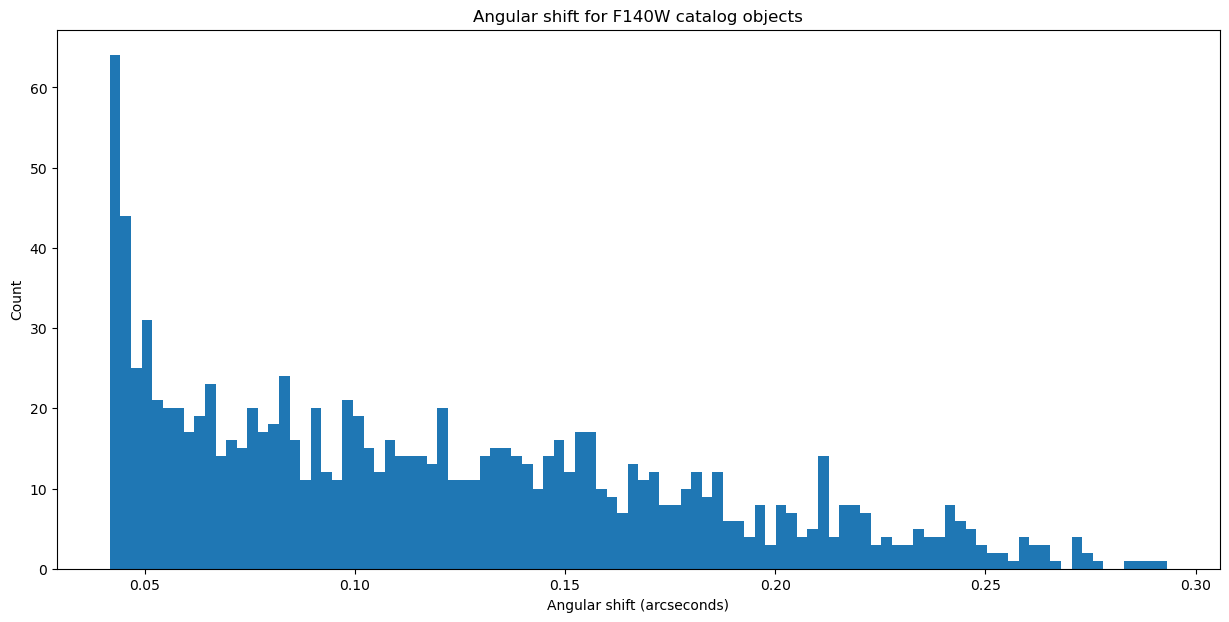

In [17]:
fig, ax = plt.subplots(1, figsize=(15,7))

ax.hist(f140w_pos_shift, bins=100)

ax.set_title('Angular shift for F140W catalog objects')
ax.set_xlabel('Angular shift (arcseconds)')
ax.set_ylabel('Count')

In [18]:
# Rewrite the F140W catalog

with open(rootdir+'HST_images/f140w_photometry_final.dat', 'w') as f:

    f.write('ID,RA,Dec,f140w_mag')
    
    for i in range(f140w_photo_cat.shape[0]):
            f.write('\n'+str(int(f140w_photo_cat[i,0])) + ',' + 
                  str(f140w_ra_new[i]) + ',' + 
                  str(f140w_dec_new[i]) + ',' +
                  str(f140w_photo_cat[i,5]))

Now rewrite the MUSE catalog

In [19]:
# Read in the MUSE catalog
muse_photo_cat = np.loadtxt(rootdir+'MUSE/pseudo_gri_photometry.dat', skiprows=1, delimiter=',', dtype=float)

In [20]:
# Create a GWCS object mapping F140W to F160W
gwcs_muse_f160w = create_gwcs_obj(star_coords_MUSE, star_coords_F160W_wcs_deg)

In [21]:
# Compute the new positions of MUSE catalog objects, along with their angular shift
muse_ra_new = np.zeros(muse_photo_cat.shape[0])
muse_dec_new = np.zeros(muse_photo_cat.shape[0])
muse_pos_shift = np.zeros(muse_photo_cat.shape[0])

for i in range(muse_photo_cat.shape[0]):
    x, y = muse_photo_cat[i,3], muse_photo_cat[i,4]
    ra_new, dec_new = gwcs_muse_f160w(x, y)
    
    ra_old, dec_old = muse_photo_cat[i,1], muse_photo_cat[i,2]
    
    # Convert RA/ Dec into radians before compute angular separations
    ra_new_rad, dec_new_rad = ra_new*np.pi/180, dec_new*np.pi/180
    ra_old_rad, dec_old_rad = ra_old*np.pi/180, dec_old*np.pi/180
        
    pos_shift = (calc_phi(ra_old_rad, dec_old_rad, ra_new_rad, dec_new_rad)*units.radian).to(units.arcsecond).value
    
    muse_ra_new[i], muse_dec_new[i], muse_pos_shift[i] = ra_new, dec_new, pos_shift

Text(0, 0.5, 'Count')

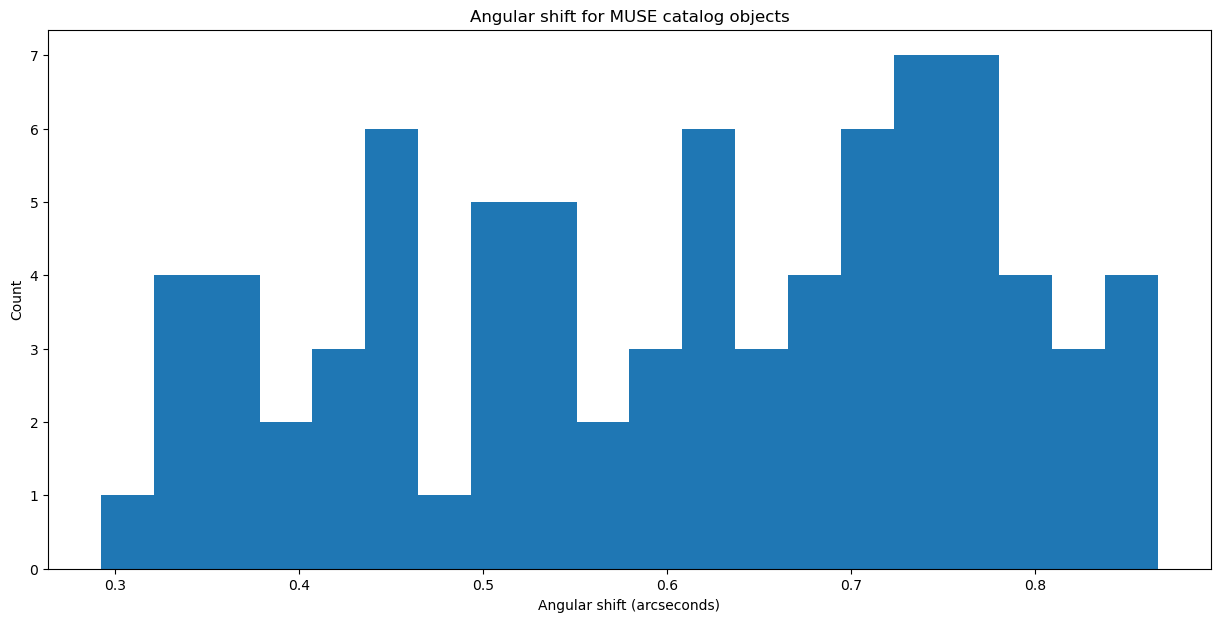

In [22]:
fig, ax = plt.subplots(1, figsize=(15,7))

ax.hist(muse_pos_shift, bins=20)

ax.set_title('Angular shift for MUSE catalog objects')
ax.set_xlabel('Angular shift (arcseconds)')
ax.set_ylabel('Count')

In [23]:
# Rewrite the MUSE catalog

with open(rootdir+'MUSE/pseudo_gri_photometry_final.dat', 'w') as f:

    f.write('ID,RA,Dec,pseudo_g_mag,pseudo_r_mag,pseudo_i_mag,z')
    
    for i in range(muse_photo_cat.shape[0]):
            f.write('\n'+str(int(muse_photo_cat[i,0])) + ',' + 
                  str(muse_ra_new[i]) + ',' + 
                  str(muse_dec_new[i]) + ',' +
                  str(muse_photo_cat[i,5]) + ',' +
                  str(muse_photo_cat[i,6]) + ',' +
                  str(muse_photo_cat[i,7]) + ',' +
                  str(muse_photo_cat[i,8]))